### Imports

In [1]:

import random
import warnings
from pathlib import Path

import torch
import torchaudio
from matplotlib import pyplot as plt
from snntorch import spikegen
from torch import nn
from tqdm import tqdm

from src.config import CONFIG
from src.preprocessing import get_snn_pipeline

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
INPUT_DIR = Path('../../data/audioMNIST')
OUTPUT_DIR = Path('../../processed/audioMNIST')

### Encoding Functions

In [3]:
def process_file(file_path: Path, pipeline: nn.Module, output_dir: Path) -> None:
    try:
        waveform, _ = torchaudio.load(file_path)
        processed = pipeline(waveform)

        # Permute to (Time, Channels, n_mels) as spikegen requires time to be first
        transposed = processed.permute(2, 0, 1)

        spikes = spikegen.delta(transposed, threshold=CONFIG.delta_threshold, off_spike=True)

        speaker = file_path.name.split('_')[1]
        class_dir = output_dir / speaker
        class_dir.mkdir(parents=True, exist_ok=True)
        save_path = class_dir / f'{file_path.stem}.pt'
        torch.save(spikes.to(torch.float32), save_path)
    except Exception as e:
        print(f'Error processing {file_path}: {e}')

def visualise_spikes(spike_tensor: torch.Tensor, number: int) -> None:
    spikes = spike_tensor.squeeze(1).detach().cpu().numpy()
    time_steps, n_mels = spikes.shape

    on_times, on_bins = (spikes == 1).nonzero()
    off_times, off_bins = (spikes == -1).nonzero()

    plt.scatter(on_times, on_bins, color='green', marker='|', s=50, label='On-spikes (+)')
    plt.scatter(off_times, off_bins, color='red', marker='|', s=50, label='Off-spikes (-)')
    plt.title(f'Spike Raster plot for {number}')
    plt.xlabel('Time Steps')
    plt.ylabel('Mel Bin')
    plt.ylim(-0.5, n_mels - 0.5)
    plt.xlim(-0.5, time_steps - 0.5)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Main

Found 30000 wav files, processing...


Processing: 100%|██████████| 30000/30000 [00:40<00:00, 745.95files/s]


Preprocessing for SNN done.


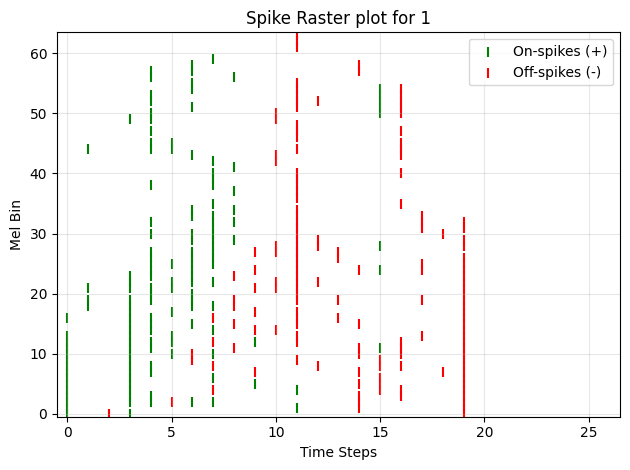

In [4]:
if __name__ == '__main__':
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    wav_files = list(INPUT_DIR.rglob('*.wav'))
    print(f'Found {len(wav_files)} wav files, processing...')

    pipeline = get_snn_pipeline()
    for f in tqdm(wav_files, desc='Processing', unit='files'):
        process_file(f, pipeline, OUTPUT_DIR)

    print('Preprocessing for SNN done.')

    # Plot a random sample to verify encoding works
    processed_files = list(OUTPUT_DIR.rglob('*.pt'))
    random_file = random.choice(processed_files)
    number = random_file.name.split('_')[0]

    spikes = torch.load(random_file)
    visualise_spikes(spikes, number)